## Preparing and Training models

### Importing libraries

In [16]:
%pip install xgboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mne
import os
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression, f_classif
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, make_scorer
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from xgboost import XGBClassifier 
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_score, KFold
from scipy.signal import hilbert
from scipy.stats import pearsonr, spearmanr
from sklearn.impute import SimpleImputer

# Ignore MNE warnings to keep the output clean
warnings.filterwarnings('ignore')

### Merging tables

In [17]:
df_demo = pd.read_csv('table/Demographics.csv')
df_bpi = pd.read_csv('table/BPI Answers.csv')
df_paindetect = pd.read_csv('table/PainDetect Answers.csv')

# Setting the ID columns to the same type
df_demo['ID'] = df_demo['ID'].astype(str)
df_bpi['ID'] = df_bpi['ID'].astype(str)
df_paindetect['ID'] = df_paindetect['ID'].astype(str)

# Merging the tables by ID
df_complete = pd.merge(df_demo, df_bpi, on='ID', how='inner')
df_complete = pd.merge(df_complete, df_paindetect, on='ID', how='inner')

df_complete = df_complete.dropna(subset=['Actual Pain'])

In [18]:
# Shows the first 5 rows of the table with all columns
display(df_complete.head())

print(f"\nTotal patients with pain scores: {df_complete.shape[0]}")
print(f"Total merged columns: {df_complete.shape[1]}")

,ID,Pain Score (Actual Pain of Brief Pain Inventory),Age,Gender,Etiology of NP*,Time with NP,Medical treatment for NP,Since when have you use the previous medication?,Have you had any medical procedures to control the pain?,Do you go regularly to phsychological or emotional counseling sessions for your pain?,...,Please write your main area of pain,Does your pain radiate to other regions of your body?,"If the answer is yes, please write the direction in which it irradiates as explicitly as possible","Do you suffer from a burning sensation (e.g., stinging nettles) in the marked areas?",Do you have a tingling or prickling sensation in the area of your pain (like crawling ants or electrical tingling)?,"Is light touching (clothing, a blanket) in this area painful?","Do you have sudden pain attacks in the area of your pain, like electric shocks?",Is cold or heat (bath water) in this area occasionally painful?,Do you suffer from a sensation of numbness in the areas that you marked?,"Does slight pressure in this area, e.g., with a finger, trigger pain?"
0,0,7.0,25.0,F,Central Nervous System Disorder (CRPS or Lyme),More than 2 years,"Pregabalin, amitriptyline",More than a year ago,Nerve blocks and infusions*,Yes,...,Soles of feet and palms of hands,Yes,"From the feet to lower back, from the hands to...",Strongly,Strongly,Strongly,Very Strongly,Very Strongly,Strongly,Moderately
1,1,4.0,57.0,F,Diabetes,More than 2 years,Tramadol,More than a month ago,NaN,No,...,Sole of feet,No,NaN,Very Strongly,Strongly,Strongly,Strongly,Strongly,Strongly,Strongly
2,2,3.0,20.0,F,Peripheral neuropathy,More than 2 years,Keterolac,More than a year ago,NaN,No,...,Wrist and hand,Yes,From the wrist to the fingers,Never,Moderately,Never,Moderately,Strongly,Very Strongly,Slightly
3,3,8.0,34.0,F,Spinal cord or nerve root injury,More than 2 years,Tramadol,More than a year ago,Physiotherapy,No,...,Lower back,No,NaN,Strongly,Moderately,Never,Never,Moderately,Never,Very Strongly
4,4,5.0,77.0,M,Spinal cord or nerve root injury,More than 2 years,NaN,NaN,NaN,No,...,"Legs, back, neck and head",Yes,To the limbs,Never,Strongly,Never,Strongly,Never,Strongly,Strongly



Total patients with pain scores: 36
Total merged columns: 35


### Definition of EEG bands and asymmetry pairs

In [19]:
bands = {
    'Theta': (4, 8),
    'Alpha': (8, 13),
    'Beta': (13, 30),
    'Gamma': (30, 40)
}

asymmetry_pairs = {
    'Fp1': 'Fp2',
    'F3': 'F4',
    'C3': 'C4',
    'P3': 'P4',
    'O1': 'O2',
    'F7': 'F8',
    'T7': 'T8',
    'P7': 'P8'
}

X_features = []
y_labels = []
feature_names = []
eeg_folder = './cleaned' 

### EEG feature extraction loop

In [20]:
for index, row in df_complete.iterrows():
    patient_id = int(row['ID'])
    pain_score = float(row['Actual Pain']) # Using BPI pain as target
    
    filename = f"ID{patient_id}_preproc_eeg.fif"
    path = os.path.join(eeg_folder, filename)
    
    if os.path.exists(path):
        try:
            # Load EEG
            raw = mne.io.read_raw_fif(path, preload=True, verbose=False)
            all_channels = raw.ch_names
            
            # Calculate PSD (Welch)
            psd = raw.compute_psd(fmin=4, fmax=40, method='welch', verbose=False)
            psd_data, freqs = psd.get_data(return_freqs=True)
            
            patient_features = []
            channel_power = {}
            temp_names = [] # Stores names only the first time
            
            # INDIVIDUAL BAND POWER
            for i, channel in enumerate(all_channels):
                channel_power[channel] = {}
                for band_name, (fmin, fmax) in bands.items():
                    band_idx = np.where((freqs >= fmin) & (freqs <= fmax))[0]
                    power = np.sum(psd_data[i, band_idx])
                    
                    channel_power[channel][band_name] = power
                    patient_features.append(power)
                    
                    if not feature_names: # Only fills names on the 1st valid iteration
                        temp_names.append(f"Pow_{channel}_{band_name}")

            # HEMISPHERE ASYMMETRY
            for left_channel, right_channel in asymmetry_pairs.items():
                if left_channel in channel_power and right_channel in channel_power:
                    for band_name in bands.keys():
                        p_left = channel_power[left_channel][band_name]
                        p_right = channel_power[right_channel][band_name]
                        
                        asymmetry = (p_right - p_left) / (p_right + p_left)
                        patient_features.append(asymmetry)
                        
                        if not feature_names:
                            temp_names.append(f"Asym_{left_channel}-{right_channel}_{band_name}")
            
            # If it's the first processed patient, save the column names
            if not feature_names:
                feature_names = temp_names
                
            X_features.append(patient_features)
            y_labels.append(pain_score)
            
            print(f"[OK] Patient {patient_id}'s EEG successfully processed.")
            
        except Exception as e:
            print(f"[ERROR] Failed on patient {patient_id}: {e}")
            
X = np.array(X_features)
y = np.array(y_labels)

print(f"EXTRACTION COMPLETED:")
print(f"Total processed patients with EEG and Table: {X.shape[0]}")
print(f"Total Biomarkers (Features) extracted per patient: {X.shape[1]}")

[OK] Patient 0's EEG successfully processed.
[OK] Patient 1's EEG successfully processed.
[OK] Patient 2's EEG successfully processed.
[OK] Patient 3's EEG successfully processed.
[OK] Patient 4's EEG successfully processed.
[OK] Patient 5's EEG successfully processed.
[OK] Patient 6's EEG successfully processed.
[OK] Patient 7's EEG successfully processed.
[OK] Patient 8's EEG successfully processed.
[OK] Patient 9's EEG successfully processed.
[OK] Patient 10's EEG successfully processed.
[OK] Patient 11's EEG successfully processed.
[OK] Patient 13's EEG successfully processed.
[OK] Patient 14's EEG successfully processed.
[OK] Patient 15's EEG successfully processed.
[OK] Patient 16's EEG successfully processed.
[OK] Patient 18's EEG successfully processed.
[OK] Patient 19's EEG successfully processed.
[OK] Patient 20's EEG successfully processed.
[OK] Patient 21's EEG successfully processed.
[OK] Patient 22's EEG successfully processed.
[OK] Patient 23's EEG successfully processed

### Machine Learning (feature selection and models)

#### SVR

In [21]:
if X.shape[0] > 0:
    print("Evaluating the Machine Learning model with Cross-Validation (K-Fold)")
    
    # Reduced to 5 to avoid memorizing the data (Overfitting)
    num_features_to_select = 5 
    
    # Creating the Pipeline (Scale -> Select Top 5 -> Train Linear SVM)
    adjusted_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('selector', SelectKBest(score_func=f_regression, k=num_features_to_select)),
        ('svr', SVR(kernel='linear', C=0.1, epsilon=0.1))
    ])
    
    # Configuring K-Fold Cross-Validation (divides the dataset into 5 parts)
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    
    # Calculating average metrics across the 5 test cycles
    scores_r2 = cross_val_score(adjusted_pipeline, X, y, cv=kf, scoring='r2')
    scores_rmse = cross_val_score(adjusted_pipeline, X, y, cv=kf, scoring='neg_root_mean_squared_error')
    
    print("\nAVERAGE PERFORMANCE OF THE SVR MODEL (CROSS-VALIDATION)")
    print(f"R-squared (R²): {scores_r2.mean():.3f} (Std dev: {scores_r2.std():.3f})")
    print(f"RMSE (Average error of the pain score): {-scores_rmse.mean():.3f}")

    adjusted_pipeline.fit(X, y)
    
    selector = adjusted_pipeline.named_steps['selector']
    mask = selector.get_support()
    final_biomarkers = np.array(feature_names)[mask]
    
    print(f"\nTOP {num_features_to_select} DEFINITIVE BIOMARKERS FOR PAIN")
    for i, bio in enumerate(final_biomarkers, 1):
        print(f"{i}. {bio}")
        
else:
    print("No patients processed. Check the paths of the .fif files!")

Evaluating the Machine Learning model with Cross-Validation (K-Fold)

AVERAGE PERFORMANCE OF THE SVR MODEL (CROSS-VALIDATION)
R-squared (R²): -0.895 (Std dev: 0.711)
RMSE (Average error of the pain score): 2.990

TOP 5 DEFINITIVE BIOMARKERS FOR PAIN
1. Asym_C3-C4_Beta
2. Asym_C3-C4_Gamma
3. Asym_P3-P4_Theta
4. Asym_P7-P8_Theta
5. Asym_P7-P8_Alpha


Graph saved as 'images\Pain_Biomarker_Correlations.png'!


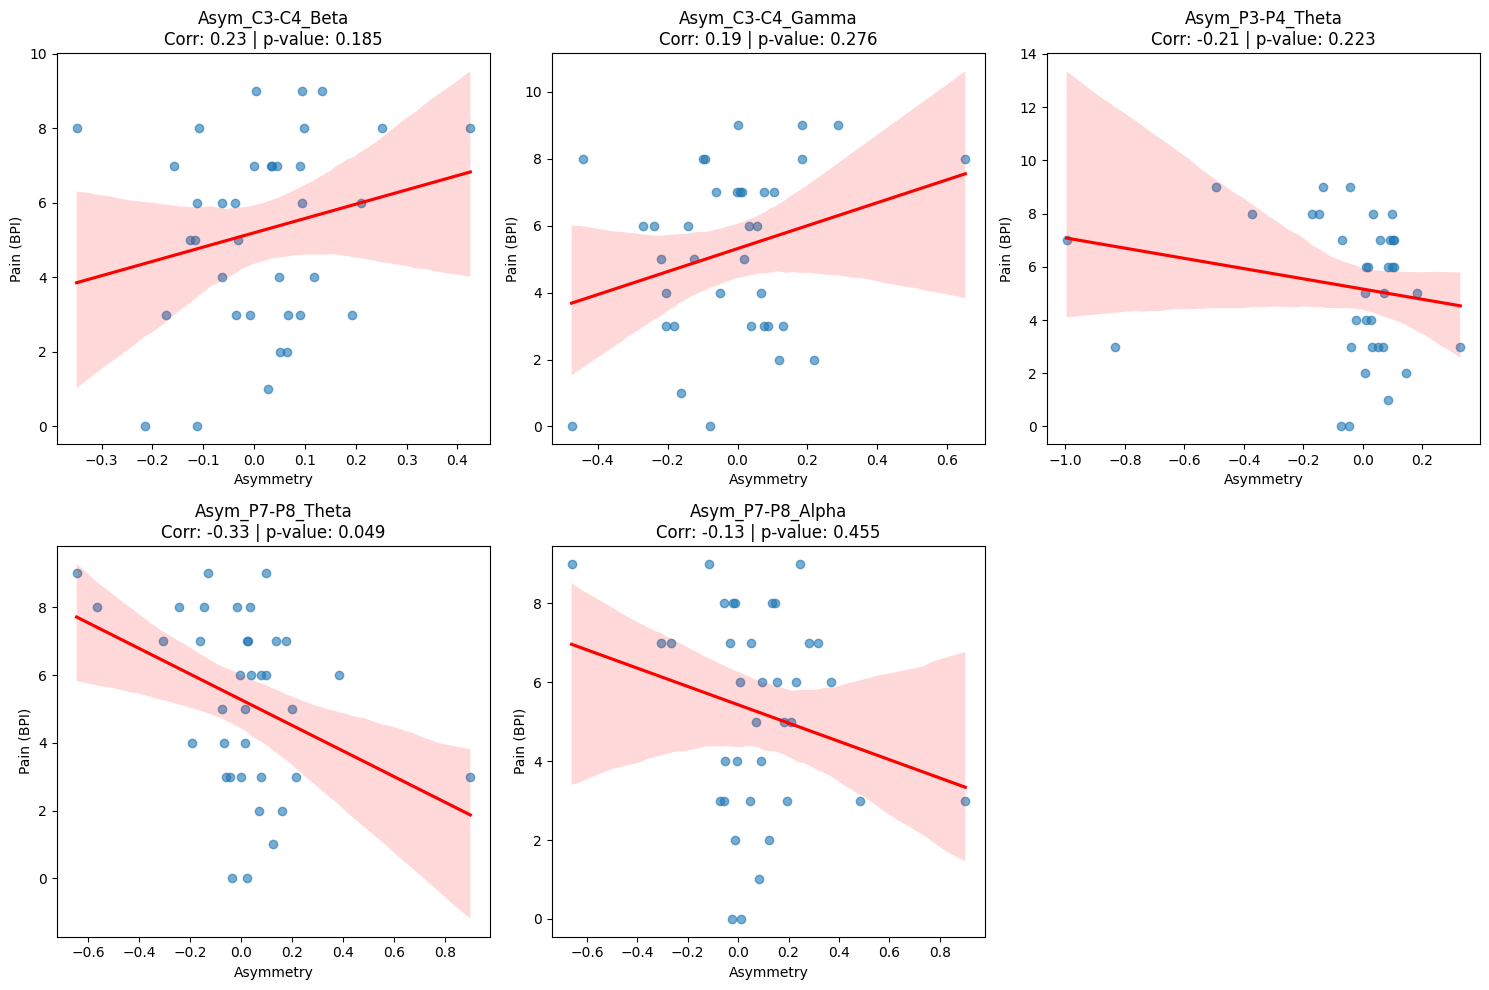

In [22]:
# Retrieve only the columns for the top 5 features
top5_indices = np.where(mask)[0]
X_top5 = X[:, top5_indices]

# Create a DataFrame to facilitate plotting
df_results = pd.DataFrame(X_top5, columns=final_biomarkers)
df_results['Pain Score'] = y

# Plot the correlation graphs
plt.figure(figsize=(15, 10))
for i, biomarker in enumerate(final_biomarkers, 1):
    plt.subplot(2, 3, i)
    sns.regplot(data=df_results, x=biomarker, y='Pain Score', 
                scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
    
    corr, p_value = spearmanr(df_results[biomarker], df_results['Pain Score'])
    
    plt.title(f"{biomarker}\nCorr: {corr:.2f} | p-value: {p_value:.3f}")
    plt.xlabel("Asymmetry")
    plt.ylabel("Pain (BPI)")

plt.tight_layout()

# Create the 'images' folder if it doesn't exist yet
os.makedirs("images", exist_ok=True)

# Define the save path inside the new folder
save_path = os.path.join("images", "Pain_Biomarker_Correlations.png")

# Save the figure
plt.savefig(save_path, dpi=300)
print(f"Graph saved as '{save_path}'!")

#### Random Forest

In [23]:
if X.shape[0] > 0:
    print("Evaluating the Random Forest model with Cross-Validation (K-Fold)...")

    num_features_to_select = 5 
    
    # Creating the new Pipeline with Random Forest
    pipeline_rf = Pipeline([
        ('scaler', StandardScaler()),
        ('selector', SelectKBest(score_func=f_regression, k=num_features_to_select)),
        ('rf', RandomForestRegressor(n_estimators=100, max_depth=3, random_state=42)) 
    ])
    
    # Configuring K-Fold Cross-Validation (divides the dataset into 5 parts)
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    
    # Calculating average metrics across the 5 test cycles
    scores_r2 = cross_val_score(pipeline_rf, X, y, cv=kf, scoring='r2')
    scores_rmse = cross_val_score(pipeline_rf, X, y, cv=kf, scoring='neg_root_mean_squared_error')
    
    print("\nAVERAGE PERFORMANCE OF THE RANDOM FOREST (CROSS-VALIDATION)")
    print(f"R-squared (R²): {scores_r2.mean():.3f} (Std dev: {scores_r2.std():.3f})")
    print(f"RMSE (Average error of the pain score): {-scores_rmse.mean():.3f}")
    
    pipeline_rf.fit(X, y)
    
    selector = pipeline_rf.named_steps['selector']
    mask = selector.get_support()
    final_biomarkers = np.array(feature_names)[mask]
    
    print(f"\nTOP {num_features_to_select} BIOMARKERS (SELECTED BY THE PIPELINE)")
    for i, bio in enumerate(final_biomarkers, 1):
        print(f"{i}. {bio}")
        
    importances = pipeline_rf.named_steps['rf'].feature_importances_
    print(f"\nIMPORTANCE GIVEN BY THE RANDOM FOREST TO EACH BIOMARKER")
    for bio, imp in zip(final_biomarkers, importances):
        print(f"- {bio}: {imp*100:.1f}% importance to the model's decision")
        
else:
    print("No patients processed. Check the paths of the .fif files!")

Evaluating the Random Forest model with Cross-Validation (K-Fold)...

AVERAGE PERFORMANCE OF THE RANDOM FOREST (CROSS-VALIDATION)
R-squared (R²): -0.804 (Std dev: 0.499)
RMSE (Average error of the pain score): 2.947

TOP 5 BIOMARKERS (SELECTED BY THE PIPELINE)
1. Asym_C3-C4_Beta
2. Asym_C3-C4_Gamma
3. Asym_P3-P4_Theta
4. Asym_P7-P8_Theta
5. Asym_P7-P8_Alpha

IMPORTANCE GIVEN BY THE RANDOM FOREST TO EACH BIOMARKER
- Asym_C3-C4_Beta: 18.9% importance to the model's decision
- Asym_C3-C4_Gamma: 20.1% importance to the model's decision
- Asym_P3-P4_Theta: 22.3% importance to the model's decision
- Asym_P7-P8_Theta: 23.4% importance to the model's decision
- Asym_P7-P8_Alpha: 15.3% importance to the model's decision


#### Random Forest with margin of tolerance

In [24]:
# Define our Flexible Accuracy function
def accuracy_with_margin(y_true, y_pred, margin=1.5):
    # Calculates the absolute difference between ground truth and prediction
    absolute_errors = np.abs(y_true - y_pred)
    
    # Counts how many errors were less than or equal to our margin
    correct_predictions = np.sum(absolute_errors <= margin)
    
    # Returns the percentage of correct predictions
    return correct_predictions / len(y_true)

# Transform this function into a 'Scorer'
margin_scorer = make_scorer(accuracy_with_margin, margin=1.5) 

# Run Cross-Validation using this new metric
print("Evaluating Regression with Margin of Tolerance (+-1.5 points)")

pipeline_rf_reg = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', SelectKBest(score_func=f_regression, k=5)),
    ('rf', RandomForestRegressor(n_estimators=100, max_depth=3, random_state=42))
])

kf = KFold(n_splits=5, shuffle=True, random_state=42)

scores_margin = cross_val_score(pipeline_rf_reg, X, y, cv=kf, scoring=margin_scorer)

print(f"Average Flexible Accuracy: {scores_margin.mean()*100:.1f}%")
print(f"Test deviation: {scores_margin.std()*100:.1f}%")

Evaluating Regression with Margin of Tolerance (+-1.5 points)
Average Flexible Accuracy: 24.6%
Test deviation: 15.7%


#### Random Forest with Classification

In [25]:
if X.shape[0] > 0:
    print("Evaluating Classification model (Severe vs Mild/Moderate Pain)...")
    
    # Transform the target (y) from continuous to binary (0 or 1)
    # Pain >= 6 becomes Class 1 (Severe). Pain < 6 becomes Class 0.
    y_class = np.where(y >= 6, 1, 0)
    
    print(f"\nClass distribution:")
    print(f"- Patients with Severe Pain (>=6): {sum(y_class == 1)}")
    print(f"- Patients with Mild/Mod Pain (<6): {sum(y_class == 0)}\n")

    num_features_to_select = 5 
    
    # Creating the Pipeline with Random Forest CLASSIFIER
    pipeline_class = Pipeline([
        ('scaler', StandardScaler()),
        ('selector', SelectKBest(score_func=f_classif, k=num_features_to_select)), 
        ('rf', RandomForestClassifier(n_estimators=100, max_depth=3, random_state=42))
    ])
    
    # StratifiedKFold ensures the proportion of severe/mild pain is equal across all tests
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    # Calculating Accuracy and AUC-ROC
    scores_acc = cross_val_score(pipeline_class, X, y_class, cv=skf, scoring='accuracy')
    scores_auc = cross_val_score(pipeline_class, X, y_class, cv=skf, scoring='roc_auc')
    
    print("CLASSIFICATION MODEL PERFORMANCE (CROSS-VALIDATION)")
    print(f"Average Accuracy: {scores_acc.mean()*100:.1f}% (Std dev: {scores_acc.std()*100:.1f}%)")
    print(f"Average AUC-ROC: {scores_auc.mean():.3f}")
 
    pipeline_class.fit(X, y_class)
    
    selector = pipeline_class.named_steps['selector']
    mask = selector.get_support()
    final_biomarkers = np.array(feature_names)[mask]
    importances = pipeline_class.named_steps['rf'].feature_importances_
    
    print(f"\nTOP {num_features_to_select} BIOMARKERS (CLASSIFICATION)")
    for bio, imp in zip(final_biomarkers, importances):
        print(f"- {bio}: {imp*100:.1f}% importance")

else:
    print("No patients processed.")

Evaluating Classification model (Severe vs Mild/Moderate Pain)...

Class distribution:
- Patients with Severe Pain (>=6): 19
- Patients with Mild/Mod Pain (<6): 17

CLASSIFICATION MODEL PERFORMANCE (CROSS-VALIDATION)
Average Accuracy: 24.6% (Std dev: 15.7%)
Average AUC-ROC: 0.242

TOP 5 BIOMARKERS (CLASSIFICATION)
- Pow_P8_Beta: 16.7% importance
- Pow_P8_Gamma: 18.9% importance
- Asym_F3-F4_Theta: 16.9% importance
- Asym_P7-P8_Theta: 23.5% importance
- Asym_P7-P8_Alpha: 24.1% importance


#### PAC (Phase-Amplitude Coupling) e XGBoost

In [26]:
def compute_pac_mi(data, sfreq, f_phase, f_amp, n_bins=18):
    # Calculates Phase-Amplitude Coupling (PAC) using the Modulation Index (MI)
    
    # Convert to 2D format required by MNE for filtering
    data_2d = np.array([data], dtype=np.float64)
    
    # Filter the signal for Phase and Amplitude frequencies
    phase_signal = mne.filter.filter_data(data_2d, sfreq, l_freq=f_phase[0], h_freq=f_phase[1], verbose=False)[0]
    amp_signal = mne.filter.filter_data(data_2d, sfreq, l_freq=f_amp[0], h_freq=f_amp[1], verbose=False)[0]
    
    # Extract Phase and Amplitude using the Hilbert Transform
    phase = np.angle(hilbert(phase_signal))
    amp = np.abs(hilbert(amp_signal))
    
    # Binning (Grouping amplitudes based on phase angle)
    bins = np.linspace(-np.pi, np.pi, n_bins + 1)
    bin_amp_mean = np.zeros(n_bins)
    
    for i in range(n_bins):
        idx = np.where((phase >= bins[i]) & (phase < bins[i+1]))[0]
        if len(idx) > 0:
            bin_amp_mean[i] = np.mean(amp[idx])
            
    # Normalize the amplitudes to create a probability distribution
    sum_amp = np.sum(bin_amp_mean)
    if sum_amp == 0:
        return 0
    p_j = bin_amp_mean / sum_amp
    
    # Calculate the Modulation Index (Shannon Entropy vs Maximum Entropy)
    h_max = np.log(n_bins)
    h = -np.sum(p_j[p_j > 0] * np.log(p_j[p_j > 0]))
    
    mi = (h_max - h) / h_max
    return mi

pac_pairs = [
    ('Theta', 'Beta'),
    ('Theta', 'Gamma'),
    ('Alpha', 'Beta'),
    ('Alpha', 'Gamma')
]

target_channels = ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'F7', 'F8', 'T3', 'T4', 'T5', 'T6', 'Fz', 'Cz', 'Pz']

X_features = []
y_labels = []
feature_names = []

print("Starting deep extraction (PSD + PAC + Asymmetries) with matrix standardization...")

for index, row in df_complete.iterrows():
    patient_id = int(float(row['ID'])) 
    pain_score = float(row['Actual Pain']) 
    path = os.path.join(eeg_folder, f"ID{patient_id}_preproc_eeg.fif")
    
    if os.path.exists(path):
        try:
            raw = mne.io.read_raw_fif(path, preload=True, verbose=False)
            all_channels = raw.ch_names
            sfreq = raw.info['sfreq']
            
            # Raw data matrix for PAC calculation (Channels x Time)
            raw_data = raw.get_data()
            
            psd = raw.compute_psd(fmin=4, fmax=40, method='welch', verbose=False)
            psd_data, freqs = psd.get_data(return_freqs=True)
            
            patient_features = []
            channel_power = {}
            channel_pac = {}
            temp_names = [] 
            
            # CHANNEL BY CHANNEL LOOP (Based on FIXED list)
            for channel in target_channels:
                if channel in all_channels:
                    i = all_channels.index(channel)
                    channel_signal = raw_data[i, :]
                    
                    # Conventional Power
                    channel_power[channel] = {}
                    for band_name, (fmin, fmax) in bands.items():
                        band_idx = np.where((freqs >= fmin) & (freqs <= fmax))[0]
                        power = np.sum(psd_data[i, band_idx])
                        channel_power[channel][band_name] = power
                        patient_features.append(power)
                        if not feature_names: temp_names.append(f"Pow_{channel}_{band_name}")
                
                    # PAC Coupling
                    channel_pac[channel] = {}
                    for (f_phase, f_amp) in pac_pairs:
                        mi = compute_pac_mi(channel_signal, sfreq, bands[f_phase], bands[f_amp])
                        pac_name = f"{f_phase}-{f_amp}"
                        channel_pac[channel][pac_name] = mi
                        patient_features.append(mi)
                        if not feature_names: temp_names.append(f"PAC_{channel}_{pac_name}")
                        
                else:
                    # CORRECTION: If the channel doesn't exist for the patient, fill with NaN
                    for band_name in bands.keys():
                        patient_features.append(np.nan)
                        if not feature_names: temp_names.append(f"Pow_{channel}_{band_name}")
                        
                    for (f_phase, f_amp) in pac_pairs:
                        patient_features.append(np.nan)
                        pac_name = f"{f_phase}-{f_amp}"
                        if not feature_names: temp_names.append(f"PAC_{channel}_{pac_name}")

            # HEMISPHERE ASYMMETRY LOOP
            for left_channel, right_channel in asymmetry_pairs.items():
                if left_channel in channel_power and right_channel in channel_power:
                    
                    # Power Asymmetry
                    for band_name in bands.keys():
                        p_left = channel_power[left_channel][band_name]
                        p_right = channel_power[right_channel][band_name]
                        asymmetry = (p_right - p_left) / (p_right + p_left)
                        patient_features.append(asymmetry)
                        if not feature_names: temp_names.append(f"Asym_Pow_{left_channel}-{right_channel}_{band_name}")
                    
                    # PAC Asymmetry
                    for (f_phase, f_amp) in pac_pairs:
                        pac_name = f"{f_phase}-{f_amp}"
                        p_left_pac = channel_pac[left_channel][pac_name]
                        p_right_pac = channel_pac[right_channel][pac_name]
                        
                        if (p_right_pac + p_left_pac) == 0:
                            asymmetry_pac = 0
                        else:
                            asymmetry_pac = (p_right_pac - p_left_pac) / (p_right_pac + p_left_pac)
                        
                        patient_features.append(asymmetry_pac)
                        if not feature_names: temp_names.append(f"Asym_PAC_{left_channel}-{right_channel}_{pac_name}")
                        
                else:
                    for band_name in bands.keys():
                        patient_features.append(np.nan)
                        if not feature_names: temp_names.append(f"Asym_Pow_{left_channel}-{right_channel}_{band_name}")
                    
                    for (f_phase, f_amp) in pac_pairs:
                        patient_features.append(np.nan)
                        pac_name = f"{f_phase}-{f_amp}"
                        if not feature_names: temp_names.append(f"Asym_PAC_{left_channel}-{right_channel}_{pac_name}")
            
            if not feature_names: feature_names = temp_names
            X_features.append(patient_features)
            y_labels.append(pain_score)
            
            print(f"[OK] Patient {patient_id}'s EEG finished.")
            
        except Exception as e:
            print(f"[ERROR] Failed on patient {patient_id}: {e}")
  
X = np.array(X_features)
y = np.array(y_labels)

print("\n EXTRACTION COMPLETED")
print(f"Total generated Biomarkers (Pow + PAC + Asymmetries): {X.shape[1]}")

valid_columns = ~np.isnan(X).all(axis=0) # Creates mask for good columns
X = X[:, valid_columns] # Filters matrix X
feature_names = np.array(feature_names)[valid_columns].tolist() # Filters names

print(f"Useful biomarkers after removing 100% missing channels: {X.shape[1]}")

if X.shape[0] > 0:
    print("Evaluating XGBoost model with the feature matrix")
    
    y_class = np.where(y >= 6, 1, 0)
    num_features_to_select = 7 
    
    # Creating the Pipeline with XGBoost
    pipeline_xgb = Pipeline([
        ('imputer', SimpleImputer(strategy='median')), 
        ('scaler', StandardScaler()),
        ('selector', SelectKBest(score_func=f_classif, k=num_features_to_select)), 
        ('xgb', XGBClassifier(
            n_estimators=100,
            max_depth=3,           # Keeps trees shallow to avoid overfitting
            learning_rate=0.05,    # Learns very slowly and steadily
            reg_alpha=1.0,         # L1 Regularization (Lasso): Zeroes out useless features
            reg_lambda=1.0,        # L2 Regularization (Ridge): Prevents absurd weights
            random_state=42,
            eval_metric='logloss'  # Silent default evaluation metric
        ))
    ])
    
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores_acc = cross_val_score(pipeline_xgb, X, y_class, cv=skf, scoring='accuracy')
    scores_auc = cross_val_score(pipeline_xgb, X, y_class, cv=skf, scoring='roc_auc')
    
    print("\nXGBOOST MODEL PERFORMANCE (CROSS-VALIDATION)")
    print(f"Average Accuracy: {scores_acc.mean()*100:.1f}%")
    print(f"Average AUC-ROC: {scores_auc.mean():.3f}")
    
    pipeline_xgb.fit(X, y_class)
    
    selector = pipeline_xgb.named_steps['selector']
    mask = selector.get_support()
    final_biomarkers = np.array(feature_names)[mask]
    importances = pipeline_xgb.named_steps['xgb'].feature_importances_
    
    print(f"\nTOP {num_features_to_select} TOTAL BIOMARKERS (XGBOOST)")
    for bio, imp in zip(final_biomarkers, importances):
        print(f"- {bio}: {imp*100:.1f}% importance")

else:
    print("No patients processed.")

Starting deep extraction (PSD + PAC + Asymmetries) with matrix standardization...
[OK] Patient 0's EEG finished.
[OK] Patient 1's EEG finished.
[OK] Patient 2's EEG finished.
[OK] Patient 3's EEG finished.
[OK] Patient 4's EEG finished.
[OK] Patient 5's EEG finished.
[OK] Patient 6's EEG finished.
[OK] Patient 7's EEG finished.
[OK] Patient 8's EEG finished.
[OK] Patient 9's EEG finished.
[OK] Patient 10's EEG finished.
[OK] Patient 11's EEG finished.
[OK] Patient 13's EEG finished.
[OK] Patient 14's EEG finished.
[OK] Patient 15's EEG finished.
[OK] Patient 16's EEG finished.
[OK] Patient 18's EEG finished.
[OK] Patient 19's EEG finished.
[OK] Patient 20's EEG finished.
[OK] Patient 21's EEG finished.
[OK] Patient 22's EEG finished.
[OK] Patient 23's EEG finished.
[OK] Patient 24's EEG finished.
[OK] Patient 25's EEG finished.
[OK] Patient 26's EEG finished.
[OK] Patient 27's EEG finished.
[OK] Patient 30's EEG finished.
[OK] Patient 31's EEG finished.
[OK] Patient 33's EEG finished.
